This notebook demonstrates the full optimization process for the first wedge and the dispersion suppressor.

Updated: 1/10/2026

# Setup

In [1]:

from scan import *
from g4beam import *
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
from scipy.optimize import differential_evolution
import re
import uuid

In [2]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


In [3]:
import scan, sys
print("scan imported from:", scan.__file__)
print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])

scan imported from: /home/incik/Cooling_4D/QQDipole/scan.py
cwd: /home/incik/Cooling_4D/QQDipole
sys.path[0]: /home/incik/miniconda3/lib/python312.zip


# Initial distribution

The parameters of the initial beam are treated as constants, but some things are known about their effects:
- **Transverse emittance**: Should be as low as possible. For this test we use an "optimistic" value of 110 microns.
- **Momentum**: Decreasing this appears to slightly decreases x-emittance.
- **Beta**: Decreasing this decreases the y-emittance growth. There may also be an optimal value for x-emittance.
- **Alpha**: Increasing this decreases the y-emittance growth, but past a certain point increases the x-emittance. I believe 0.7 focuses the beam onto the wedge center with a VD distance of 24 mm.
- **Longitudinal emittance**: Effects not yet tested.
- **Standard deviation of momentum**: Decreasing this decreases the x-emittance.
- **Virtual detector distance**: Almost irrelevant. Should be more than 3x the length of the wedge to ensure accurate measurements.

In [4]:
t_emit = 0.145  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 0.7     # dimensionless
l_emit = 1      # mm
pz_std = 1    # MeV/c
vd_dist = 24    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
pre_w1["PDGid"] = -13
print_all_params(pre_w1)

-----------------------------
Twiss parameters for X
emit  = 0.1452779753109065 mm
beta  = 0.02991493676722865 m
gamma = 50.17839269602016 1/m
alpha = 0.7078724776275814
D     = -0.0008830916009469487 m
D'    = -0.016770713148590535

Twiss parameters for Y
emit  = 0.14538726975853142 mm
beta  = 0.029893084439790333 m
gamma = 50.130256402891916 1/m
alpha = 0.7060793069053842
D     = 0.0009677860438324247 m
D'    = 0.02300678977621541

Z-emittance:  1.2667119749004823 mm
Z std: 154.75203019434983 mm
p std: 0.9902853418731606 MeV/c
Mean momentum: 100.00237592005227 MeV/c
-----------------------------


In [5]:
write_trackfile(pre_w1, "particles_before.txt")

# First wedge

Determines the optimal length and angle for the first wedge

In [6]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

start = time.time()
# Run optimization
optim_result = minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w1_length, w1_angle = optim_result.x
print(f"Length = {w1_length:.2f} mm\nAngle = {w1_angle:.1f} deg")
print("Time spent:", time.time()-start)

# Runs a single case with the optimal parameters
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
print_all_params(post_w1)
print_all_params(cut_outliers(post_w1))

iter value
  41 4.21394e-02
Length = 7.51 mm
Angle = 47.4 deg
Time spent: 933.6193704605103
-----------------------------
Twiss parameters for X
emit  = 0.04426855512928518 mm
beta  = 0.035862593710499935 m
gamma = 198.80455969426825 1/m
alpha = -2.4758124226423885
D     = 0.019328324265112953 m
D'    = -0.05167818917154716

Twiss parameters for Y
emit  = 0.1515600476634262 mm
beta  = 0.025231286254144912 m
gamma = 59.157155349715005 1/m
alpha = -0.7018626080719638
D     = 0.0001125468832413481 m
D'    = 0.004758175347332022

Z-emittance:  6.50729201362495 mm
Z std: 142.92481860744928 mm
p std: 7.356005563109029 MeV/c
Mean momentum: 87.1956172228445 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.04213940056558521 mm
beta  = 0.036684346441432945 m
gamma = 204.48184821132546 1/m
alpha = -2.5497613536895503
D     = 0.01953629284592834 m
D'    = -0.059026943224472904

Twiss parameters for Y
emit  = 0.1492694850416578 mm
beta  = 0.02515807

In [7]:
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
print_all_params(post_w1)
print_all_params(cut_outliers(post_w1))

-----------------------------
Twiss parameters for X
emit  = 0.04426855512928518 mm
beta  = 0.035862593710499935 m
gamma = 198.80455969426825 1/m
alpha = -2.4758124226423885
D     = 0.019328324265112953 m
D'    = -0.05167818917154716

Twiss parameters for Y
emit  = 0.1515600476634262 mm
beta  = 0.025231286254144912 m
gamma = 59.157155349715005 1/m
alpha = -0.7018626080719638
D     = 0.0001125468832413481 m
D'    = 0.004758175347332022

Z-emittance:  6.50729201362495 mm
Z std: 142.92481860744928 mm
p std: 7.356005563109029 MeV/c
Mean momentum: 87.1956172228445 MeV/c
-----------------------------
-----------------------------
Twiss parameters for X
emit  = 0.04213940056558521 mm
beta  = 0.036684346441432945 m
gamma = 204.48184821132546 1/m
alpha = -2.5497613536895503
D     = 0.01953629284592834 m
D'    = -0.059026943224472904

Twiss parameters for Y
emit  = 0.1492694850416578 mm
beta  = 0.025158075647595403 m
gamma = 58.42655396025008 1/m
alpha = -0.6854922788480452
D     = 6.95950142163

In [8]:
# Optimized G4_FinalCooling_auto.g4bl parameters
offset = w1_length / (math.tan(w1_angle * math.pi / 180) * 2)
base_length = 2*offset
abswidth = 100
parameters = dict(
        abshalfangle3=str(w1_angle),
        absoffset3=str(offset),
        abshgt=str(offset * base_length / w1_length + 0.1),
        absLEN3=str(base_length)
    )
L_centerline = float(parameters['absLEN3']) + 1
print("Where to put the next element: " + str(L_centerline) + "mm")

Where to put the next element: 7.906557209985696mm


In [9]:
# Write the wedge output into a file
write_trackfile(post_w1, "particles_after.txt")

In [10]:
# If particles_after isn't updated with Z = 0.
def convertZ(input_file, output_file, set_to=0):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = str(set_to)  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None

In [11]:
convertZ("particles_after.txt", "particles_afterupt.txt", set_to=0.0)

Updated file saved as 'particles_afterupt.txt'


# Dispersion correction optimization

The main goal is to have $D_x \approx 0$ up to 1e-5 m while keeping $\beta_x$ relatively periodic and about at the same value.

In [12]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, replacements, out_path):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In [13]:
def clean_field_files():
    for f in ["field_cellQ1.dat", "field_cellQ2.dat"]:
        if os.path.exists(f):
            os.remove(f)


In [14]:
# Initial Values Post-Wedge
x0_params, y0_params, _ = calc_all_params(post_w1)
beta_x_ref= x0_params[1]; beta_y_ref= y0_params[1]
print(r"$\beta_x$: " + str(beta_x_ref), r"$\beta_y$: " + str(beta_y_ref))
print("D_x: " + str(x0_params[4]), "D_y: " + str(y0_params[4]))

$\beta_x$: 0.035862593710499935 $\beta_y$: 0.025231286254144912
D_x: 0.019328324265112953 D_y: 0.0001125468832413481


In [15]:
def run_two_quadrupoles(df, Q1_length, Q1_gradient, Q2_length, Q2_gradient, Q1_radius, Q2_radius, Drift1_length, Q1_z=L_centerline, thickness=5):
    """
    Runs G4BL with two sequential quadrupoles.
    """
    Drift1_width=2*max(Q1_radius,Q2_radius)
    Drift1_height=2*max(Q1_radius,Q2_radius)
    # Q1_z : f"{L_centerline + (Q1_length / 2):.12f}",
    params = {
    "Q1_z": f"{Q1_z + (Q1_length / 2):.12f}",
    "Q1_length": f"{Q1_length:.12f}",
    "Q1_gradient": f"{Q1_gradient:.12f}",
    "radius_q1": f"{Q1_radius:.12f}",
    "radius_q2": f"{Q2_radius:.12f}",
    "thickness": f"{thickness:.12f}",
    "Q1_end": f"{Q1_z + Q1_length:.12f}",
    "Q2_length":f"{Q2_length:.12f}",
    "Q2_gradient": f"{Q2_gradient:.12f}",
    "Drift1_length": f"{Drift1_length:.12f}",
    "Drift1_z": f"{Q1_z + Q1_length + (Drift1_length / 2):.12f}",
    "Drift1_width": f"{Drift1_width:.12f}", 
    "Drift1_height":f"{Drift1_height:.12f}", 
    "D1_end": f"{Q1_z + Q1_length + Drift1_length:.12f}",
    "Q2_z": f"{Q1_z + Q1_length + Drift1_length + Q2_length/2:.12f}",
    "Q2_end": f"{Q1_z + Q1_length + Drift1_length + Q2_length:.12f}"
    }

    print("PARAMS PASSED TO TEMPLATE:")
    for k, v in params.items():
        print(k, "=", v)
    write_input_from_template("G4_FinalCooling_dispsup_Q2.g4bl", params, "G4_FinalCooling_dispsup_Q2_run.g4bl")
    
    # Run this file
    clean_field_files()
    res = run_g4beam(df, "G4_FinalCooling_dispsup_Q2_run.g4bl")

    if res is None or len(res) < 10:
        print("G4BL run failed or empty. Check template and parameters.")
        return None
    return res

In [18]:
history = []
def optimize_qq_drift_safe(x, df, beta_x_ref, beta_y_ref,
                           w_disp=1.0, w_beta=10.0, w_surv=100.0):
    """
    Optimizer wrapper with:
    - Survival-aware penalty
    - Full diagnostics
    """

    q1_length, q1_gradient, q2_length, q2_gradient, q1_radius, q2_radius, d_length = x
    print("\nTRYING x =", x)

    try:
        result = run_two_quadrupoles(
            df,
            Q1_length=q1_length,
            Q1_gradient=q1_gradient,
            Q2_length=q2_length,
            Q2_gradient=q2_gradient,
            Q1_radius=q1_radius,
            Q2_radius=q2_radius,
            Drift1_length=d_length
        )
    except Exception as e:
        print("EXCEPTION in run_two_quadrupoles:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # Compute survival fraction
    N0 = 2000 # len(df)
    Ns = len(result)
    survival = Ns / N0
    survival_penalty = w_surv * (1.0 - survival)**2
    print(f"Particles survived: {Ns}/{N0} → penalty {survival_penalty:.3f}")

    # Compute optics parameters
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5

    Dx = x_params[4]
    Dy = y_params[4]
    beta_x = x_params[1]
    beta_y = y_params[1]

    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2
    eps = 1e-4

    # Log-scaled optics loss
    optics_loss = np.log(Dx**2 + eps) + np.log(beta_penalty**2 + eps)

    # Total objective
    val = optics_loss + survival_penalty

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, beta_penalty={beta_penalty:.6f}")
    history.append({
    "Q1_L": q1_length,
    "Q1_G": q1_gradient,
    "Q2_L": q2_length,
    "Q2_G": q2_gradient,
    "Q1_radius": q1_radius,
    "Q2_radius": q2_radius,
    "Drift1_L": d_length,
    "Dx": Dx,
    "beta_x": beta_x,
    "beta_y": beta_y,
    "survival": survival,
    "objective": val})

    return val


In [20]:
x0 = [121.21526189, 1, 139.77335625, -17.64495411, 100, 100, 200]
# Physical bounds
bounds = np.array([
    [50, 2000],   # Q1_length
    [1, 30],      # Q1_gradient
    [50, 2000],   # Q2_length
    [-30, -1],    # Q2_gradient
    [10, 500],    # Q1_radius
    [10, 500],    # Q2_radius
    [20, 1000]    # Drift1_length
])
res = scipy.optimize.minimize(
    optimize_qq_drift_safe, x0,
    args=(post_w1, beta_x_ref, beta_y_ref),
    method="Nelder-Mead", bounds=bounds,
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)
print("Optimal parameters:", res.x)


TRYING x = [121.21526189   1.         139.77335625 -17.64495411 100.
 100.         200.        ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 68.514188154986
Q1_length = 121.215261890000
Q1_gradient = 1.000000000000
radius_q1 = 100.000000000000
radius_q2 = 100.000000000000
thickness = 5.000000000000
Q1_end = 129.121819099986
Q2_length = 139.773356250000
Q2_gradient = -17.644954110000
Drift1_length = 200.000000000000
Drift1_z = 229.121819099986
Drift1_width = 200.000000000000
Drift1_height = 200.000000000000
D1_end = 329.121819099986
Q2_z = 399.008497224986
Q2_end = 468.895175349986
Particles survived: 1615/2000 → penalty 3.706
OBJECTIVE = 7.506116, Dx=-0.017770, beta_penalty=327.973628

TRYING x = [127.27602498   1.         139.77335625 -17.64495411 100.
 100.         200.        ]
PARAMS PASSED TO TEMPLATE:
Q1_z = 71.544569702236
Q1_length = 127.276024984500
Q1_gradient = 1.000000000000
radius_q1 = 100.000000000000
radius_q2 = 100.000000000000
thickness = 5.000000000000
Q1_end = 135.18258219448

In [23]:
# [165.44850696   1.         117.80564137 -16.64715284  10. 20.        ]
# [203.10586964   1.         242.37880814  -7.24549651  10. 20.        ]
print(res.x)

[100.72718287   1.          73.38255945 -29.88222576 156.53533389
  79.70529563 201.58167625]


In [24]:
if os.path.exists("field_cellQ2.dat"):
    os.remove("field_cellQ2.dat")
df_opt = run_two_quadrupoles(post_w1, Q1_length=res.x[0], Q1_gradient=res.x[1],
                             Q2_length=res.x[2], Q2_gradient=res.x[3],
                             Q1_radius=res.x[4], Q2_radius=res.x[5], Drift1_length=res.x[5])
print(df_opt)

PARAMS PASSED TO TEMPLATE:
Q1_z = 58.270148642901
Q1_length = 100.727182865830
Q1_gradient = 1.000000000000
radius_q1 = 156.535333887281
radius_q2 = 79.705295632931
thickness = 5.000000000000
Q1_end = 108.633740075816
Q2_length = 73.382559452582
Q2_gradient = -29.882225757177
Drift1_length = 79.705295632931
Drift1_z = 148.486387892282
Drift1_width = 313.070667774561
Drift1_height = 313.070667774561
D1_end = 188.339035708747
Q2_z = 225.030315435038
Q2_end = 261.721595161329
             x          y        z        Px         Py       Pz         t  \
0    -16.50660   0.836939  261.722 -13.80210  -0.664915  95.1828  1.653710   
1    -56.81740  14.198200  261.722 -42.76860  -3.126580  78.9938  0.670012   
2     -4.62706  16.495600  261.722  -3.31720  -6.048590  84.8545  1.594100   
3    -64.04830 -33.818700  261.722 -45.44370  10.276800  68.8910  0.939761   
4     -9.10880 -44.258900  261.722  -6.92502  12.125300  88.0484  2.518980   
...        ...        ...      ...       ...        ..

In [25]:
x_params, y_params, z_emit = calc_all_params(df_opt)
print("Dx, Dy =", x_params[4], y_params[4])

Dx, Dy = 0.02852616097699773 0.0007019720683630097


In [24]:
b_dict = {"Beta_x" : x_params[1], "Beta_y" : y_params[1]}
print(b_dict, x_params[4])

{'Beta_x': np.float64(1.5184525896846939), 'Beta_y': np.float64(0.38508275236723966)} 0.006341240796552948


In [ ]:
if os.path.exists("particles_after_q2upt.txt"):
    os.remove("particles_after_q2upt.txt")
convertZ("particles_after_q2.txt", "particles_after_q2upt.txt", set_to=0.0)

In [25]:
with open("particles_after_q2upt.txt") as f:
    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out)
N_PARTICLES = 2000
# Compute transmission (%)
trans_percent = 100.0 * N_out / int(N_PARTICLES)
print(trans_percent)

12
2.4


In [26]:
def check_dipole_clearance(df, B_val, dipole_length_mm, dipole_halfwidth_mm):
    """
    Check which particles clear the dipole aperture based on their Larmor radius
    and deflection geometry.

    Parameters:
      df : pandas.DataFrame with columns ['Px','Py','Pz'] in MeV/c
      B_val : magnetic field (Tesla)
      dipole_length_mm : dipole magnet effective length (mm)
      dipole_halfwidth_mm : half-width of dipole aperture (mm)

    Returns:
      surviving_mask : boolean array, True if particle clears aperture
      r_L_mm : array of Larmor radii (mm)
      delta_r_mm : array of deflections (mm)
    """

    # constants
    e = 1.602176634e-19  # C
    c = 2.99792458e8     # m/s

    # convert MeV/c to SI (kg·m/s)
    mom_perp = np.sqrt(df["Px"]**2 + df["Pz"]**2) * 1e6 * e / c  # B assumed along y

    # Larmor radius [m]
    r_L = mom_perp / (e * np.abs(B_val))

    # convert to mm
    r_L_mm = r_L * 1e3
    s_mm = dipole_length_mm

    # deflection Δr = r * (1 - cos(φ)), φ = s / r
    phi = s_mm / r_L_mm
    delta_r_mm = r_L_mm * (1 - np.cos(phi))

    # check if deflection < half-width
    surviving_mask = delta_r_mm < dipole_halfwidth_mm


    return surviving_mask, r_L_mm, delta_r_mm

In [28]:
def run_dipole(df, B_field, B_length, Drift2_length, B_width=100, B_height=100, Drift2_z=0):
    """Run dipole simulation with given parameters."""
    params = {
        "Drift2_length": Drift2_length, 
        "Drift2_width": B_width,
        "Drift2_height": B_height,
        "Drift2_z": Drift2_z + Drift2_length/2,
        "B1_field": B_field,
        "B1_z": Drift2_z + Drift2_length + B_length/2,
        "B1_end": Drift2_z + Drift2_length + B_length,
        "B1_length": B_length,
        "B1_width": B_width,
        "B1_height": B_height
    }
    write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", params, "G4_FinalCooling_dispsup_B_run.g4bl")
    outfile = "G4_FinalCooling_dispsup_B_run.g4bl"
    return run_g4beam(df, "G4_FinalCooling_dispsup_B_run.g4bl")

In [80]:
history_d =[]
def optimize_dipole_safe(x, df, beta_x_ref, beta_y_ref,
                         w_disp=1000.0, w_beta=10.0, w_surv=100.0):
    """
    Dipole optimizer with smooth survival penalty
    x = [B_field, B_length, Drift2_length]
    """

    B_field, B_length, Drift2_length = x
    print("\nTRYING dipole x =", x)

    try:
        result = run_dipole(df, B_field, B_length, Drift2_length)
    except Exception as e:
        print("EXCEPTION in run_dipole:", e)
        return 1e6

    if result is None or len(result) == 0:
        print("No particles survived")
        return 1e6

    # --- Survival (ground truth from G4BL)
    N0 = len(df)
    Ns = len(result)
    survival = Ns / N0
    survival_penalty = w_surv * (1.0 - survival)**2

    print(f"Survival: {Ns}/{N0} → penalty {survival_penalty:.3f}")

    # --- Optics
    try:
        x_params, y_params, _ = calc_all_params(result)
    except Exception as e:
        print("EXCEPTION in calc_all_params:", e)
        return 1e5

    Dx = x_params[4]
    beta_x = x_params[1]
    beta_y = y_params[1]

    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 \
                 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    eps = 1e-6
    optics_loss = np.log(Dx**2 + eps) + np.log(beta_penalty**2 + eps)

    val = optics_loss + survival_penalty

    print(f"OBJECTIVE = {val:.6f}, Dx={Dx:.6f}, beta_penalty={beta_penalty:.6f}")
    history_d.append({
        "B_F": B_field,
        "B_L": B_length,
        "D2_L": Drift2_length,
        "Dx": Dx,
        "beta_x": beta_x,
        "beta_y": beta_y,
        "survival": survival,
        "objective": val})
    return val


In [86]:
# initial guess: B_field (T), B_length (mm), Drift2_length (mm)
x0_dip = [1.5, 200.0, 100.0]

# bounds
bounds_dip = [(0.1, 3.0),  # B_field
              (50, 400),   # B_length
              (20, 1000)]  # Drift2_length

res_dip = minimize(optimize_dipole_safe, x0_dip, args=(df_opt, b_dict['Beta_x'], b_dict['Beta_y']),
                method="Nelder-Mead", bounds=bounds_dip)

print("Optimal dipole parameters:", res_dip.x)

iter value

TRYING dipole x = [  1.5 200.  100. ]
Survival: 6/20 → penalty 49.000
OBJECTIVE = 59.811778, Dx=-0.111660, beta_penalty=1994.493140

TRYING dipole x = [  1.575 200.    100.   ]
Survival: 6/20 → penalty 49.000
OBJECTIVE = 59.811778, Dx=-0.111660, beta_penalty=1994.493140

TRYING dipole x = [  1.5 210.  100. ]
Survival: 6/20 → penalty 49.000
OBJECTIVE = 60.075859, Dx=-0.114710, beta_penalty=2215.517490

TRYING dipole x = [  1.5 200.  105. ]
Survival: 7/20 → penalty 42.250
OBJECTIVE = 45.079989, Dx=0.005497, beta_penalty=736.762714

TRYING dipole x = [  1.55       190.         103.33333333]
Survival: 6/20 → penalty 49.000
OBJECTIVE = 59.631187, Dx=-0.109627, beta_penalty=1856.078393
   1 4.50800e+01
TRYING dipole x = [  1.45833333 193.33333333 105.55555556]
Survival: 7/20 → penalty 42.250
OBJECTIVE = 44.964564, Dx=0.005535, beta_penalty=690.778578

TRYING dipole x = [  1.4        190.         108.33333333]
Survival: 7/20 → penalty 42.250
OBJECTIVE = 44.954468, Dx=0.005539, bet

In [87]:
df_opt_d = run_dipole(df_opt, B_field=res_dip.x[0], B_length=res_dip.x[1], Drift2_length=res_dip.x[2])
x_params_d, y_params_d, z_emit_d = calc_all_params(df_opt_d)
print("Dx Dy: ", x_params_d[4], y_params_d[4])
print("Betax Betay: ", x_params_d[1], y_params_d[1])

Dx Dy:  -0.026926337360847923 -0.0003816609062427824
Betax Betay:  1.5184974942993732 0.3984617002766998


In [91]:
def parse_g4bl_file(filename):
    with open(filename) as f:
        text = f.read()

    pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
    entries = dict(re.findall(pattern, text))

    return {k: float(v) for k, v in entries.items()}

def build_magnet_regions(params):
    magnet_colors = {
        "wedge":  "#FF66CC",
        "Q1":     "#6699FF",
        "Drift1": "#BBBBBB",
        "Q2":     "#3366CC",
        "Drift2": "#999999",
        "B1":     "#FFAA33",
    }

    magnet_order = ["wedge", "Q1", "Drift1", "Q2", "Drift2", "B1"]
    regions = []

    for name in magnet_order:
        z_key = f"{name}_z"
        L_key = f"{name}_length"

        if name == "wedge":
            if "wedge_end" in params:
                z1 = 0.0
                z2 = params["wedge_end"]
                regions.append((z1, z2, magnet_colors[name], name))

        elif z_key in params and L_key in params:
            center = params[z_key]
            length = params[L_key]
            z1 = center - length / 2
            z2 = center + length / 2
            regions.append((z1, z2, magnet_colors[name], name))

    return regions

In [92]:
def twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y, output_folder="./dispsup_plots"):
    
    # -------------------------------------------------------------------
    # CONVERT TO ARRAYS FOR PLOTTING
    # -------------------------------------------------------------------
    z_positions = np.array(z_positions)
    order = np.argsort(z_positions)

    z_positions = z_positions[order]
    emit_x = np.array(emit_x)[order]
    emit_y = np.array(emit_y)[order]
    beta_x = np.array(beta_x)[order]
    beta_y = np.array(beta_y)[order]
    alpha_x = np.array(alpha_x)[order]
    alpha_y = np.array(alpha_y)[order]
    D_x = np.array(D_x)[order]
    Dp_x = np.array(Dp_x)[order]
    D_y = np.array(D_y)[order]
    Dp_y = np.array(Dp_y)[order]
    emit_z = np.array(emit_z)[order]

    # -------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------
    def make_plot(yvals, ylabel, title, filename, labels=("x", "y")):
        plt.figure(figsize=(7,5))

        # ---- draw magnet shading (already parsed) ----
        for z1, z2, color, label in regions:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)

        # ---- twiss curves ----
        plt.plot(z_positions, yvals[0], 'o-', color="#541352FF", label=f"{labels[0]}-plane")
        plt.plot(z_positions, yvals[1], 's--', color="#3A5E8CFF", label=f"{labels[1]}-plane")

        plt.xlabel("z [mm]")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True)

        # ---- remove duplicate legend entries ----
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, filename))
        plt.close()


    make_plot((emit_x, emit_y), "Emittance [mm·mrad]",
            "Emittance Evolution", "emittance_evolution.png")

    make_plot((beta_x, beta_y), "β-function [m]",
            "Beta Function Evolution", "beta_evolution.png")

    make_plot((alpha_x, alpha_y), "α-function [–]",
            "Alpha Function Evolution", "alpha_evolution.png")

    make_plot((D_x, D_y), "Dispersion D [m]",
            "Dispersion Function", "dispersion_D.png")

    make_plot((Dp_x, Dp_y), "Dispersion Derivative D' [-]",
            "Dispersion Derivative", "dispersion_Dprime.png")

    print(f"All plots saved in '{output_folder}'")


files = ["vd_start_dispsup.txt", "vd_Q1_dispsup.txt", "vd_D1_dispsup.txt", "particles_after_q2uptc.txt", "particles_after_b.txt"]
z_positions = []
emit_x = []
emit_y = []
emit_z = []
beta_x = []
beta_y= []
alpha_x=[]
alpha_y=[]
D_x=[]
Dp_x=[]
D_y=[]
Dp_y=[]

for i in files:
        df1 = read_trackfile(i)
        z_positions.append(np.mean(df1["z"]))
        x_params1, y_params1, z_emit1 = calc_all_params(df1)
        ex, bx, gx, ax, Dx, Dxp = x_params1
        ey, by, gy, ay, Dy, Dyp = y_params1
        emit_x.append(ex)
        emit_y.append(ey)
        beta_x.append(bx)
        beta_y.append(by)
        alpha_x.append(ax)
        alpha_y.append(ay)
        D_x.append(Dx), Dp_x.append(Dxp), D_y.append(Dy), Dp_y.append(Dyp)
        emit_z.append(z_emit1)

g4bl_files = [
    "G4_FinalCooling_dispsup_Q2_run.g4bl",
    "G4_FinalCooling_dispsup_B_run.g4bl",
]

params = {}
for f in g4bl_files:
    params.update(parse_g4bl_file(f))

regions = build_magnet_regions(params)


twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y)

All plots saved in './dispsup_plots'


# Scrap

In [ ]:
df_hist = pd.DataFrame(history)
plt.figure(figsize=(6,5))

sc = plt.scatter(
    df_hist["Q1_G"],
    df_hist["Q2_G"],
    c=df_hist["objective"].values,
    cmap="viridis",
    s=40
)

best = df_hist.loc[df_hist["objective"].idxmin()]
plt.scatter(
    best["Q1_G"],
    best["Q2_G"],
    color="red",
    s=120,
    label="Best"
)

plt.colorbar(sc, label="Objective")
plt.xlabel("Q1 gradient")
plt.ylabel("Q2 gradient")
plt.title("Quad optimization search space")
plt.legend()
plt.show()

plt.scatter(
    df_hist["Q1_G"],
    df_hist["Q2_G"],
    c=df_hist["survival"],
    cmap="plasma",
    s=40
)
plt.colorbar(label="Survival fraction")
plt.xlabel("Q1 gradient (T/m)")
plt.ylabel("Q2 gradient (T/m)")
plt.title("Survival across quad parameter space")
plt.show()
plt.figure()
sc= plt.scatter(df_hist["Dx"], df_hist["objective"], c=df_hist["beta_x"].values, cmap="plasma", alpha=0.6)
plt.colorbar(sc, label="beta_x")
plt.xlabel("Dx (m)")
plt.ylabel("Objective")
plt.title("Dispersion vs objective")
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(
    df_hist["Q1_G"],
    df_hist["Q2_G"],
    c=df_hist["Dx"].values,
    cmap="viridis",
    s=40
)

best = df_hist.loc[df_hist["Dx"].idxmin()]
plt.scatter(
    best["Q1_G"],
    best["Q2_G"],
    color="red",
    s=120,
    label="Best"
)

plt.colorbar(sc, label="Dx")
plt.xlabel("Q1 gradient (T/m)")
plt.ylabel("Q2 gradient (T/m)")
plt.title("Quad optimization search space")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(
    df_hist["Q1_G"],
    df_hist["Q2_G"],
    c=df_hist["beta_x"].values,
    cmap="viridis",
    s=40
)

best = df_hist.loc[df_hist["beta_x"].idxmin()]
plt.scatter(
    best["Q1_G"],
    best["Q2_G"],
    color="red",
    s=120,
    label="Best"
)

plt.colorbar(sc, label="beta_x")
plt.xlabel("Q1 gradient (T/m)")
plt.ylabel("Q2 gradient (T/m)")
plt.title("Quad optimization search space")
plt.legend()
plt.show()


In [ ]:
df_hist_b = pd.DataFrame(history_d)
plt.figure(figsize=(6,5))

sc = plt.scatter(
    df_hist_b["B_F"],
    df_hist_b["B_L"],
    c=df_hist_b["objective"].values,
    cmap="viridis",
    s=40
)

best = df_hist_b.loc[df_hist_b["objective"].idxmin()]
plt.scatter(
    best["B_F"],
    best["B_L"],
    color="red",
    s=120,
    label="Best"
)

plt.colorbar(sc, label="Objective")
plt.xlabel("B field strength (T)")
plt.ylabel("B length (mm)")
plt.title("Dipole optimization search space")
plt.legend()
plt.show()

plt.scatter(
    df_hist_b["B_F"],
    df_hist_b["B_L"],
    c=df_hist_b["survival"],
    cmap="plasma",
    s=40
)
plt.colorbar(label="Survival fraction")
plt.xlabel("B field strength (T)")
plt.ylabel("B length (mm)")
plt.title("Survival across quad parameter space")
plt.show()
plt.figure()
sc= plt.scatter(df_hist_b["Dx"], df_hist_b["objective"], c=df_hist_b["beta_x"].values, cmap="plasma", alpha=0.6)
plt.colorbar(sc, label="beta_x")
plt.xlabel("Dx")
plt.ylabel("Objective")
plt.title("Dispersion vs objective")
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(
    df_hist_b["B_F"],
    df_hist_b["B_L"],
    c=df_hist_b["Dx"].values,
    cmap="viridis",
    s=40
)

best = df_hist_b.loc[df_hist_b["Dx"].abs().idxmin()]
plt.scatter(
    best["B_F"],
    best["B_L"],
    color="red",
    s=120,
    label="Best"
)


plt.colorbar(sc, label="Dx")
plt.xlabel("B field strength (T)")
plt.ylabel("B length (mm)")
plt.title("Dipole optimization search space")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(
    df_hist_b["B_F"],
    df_hist_b["B_L"],
    c=df_hist_b["beta_x"].values,
    cmap="viridis",
    s=40
)

best = df_hist_b.loc[df_hist_b["beta_x"].idxmin()]
plt.scatter(
    best["B_F"],
    best["B_L"],
    color="red",
    s=120,
    label="Best min"
)
best_max = df_hist_b.loc[df_hist_b["beta_x"].idxmax()]
plt.scatter(
    best_max["B_F"],
    best_max["B_L"],
    color="blue",
    s=120,
    label="Best max"
)

plt.colorbar(sc, label="beta_x")
plt.xlabel("B field strength (T)")
plt.ylabel("B length (mm)")
plt.title("Dipole optimization search space")
plt.legend()
plt.show()


## Let's now try to max beta in quads and min it in dipoles

In [59]:
history_beta = []
def optimize_qq_drift_beta(x, df, beta_min=1.0, beta_max=2.0,w_surv=200.0, w_beta=50.0, w_disp=1.0):
    """
    Quad optimizer:
    - Strongly maximize survival
    - Maximize beta within [beta_min, beta_max]
    - Weakly minimize dispersion
    """

    bounds = np.array([
        [50, 2000],   # Q1_length
        [1, 30],      # Q1_gradient
        [50, 2000],   # Q2_length
        [-30, -1],    # Q2_gradient
        [10, 500],    # Q_radius
        [20, 1000]    # Drift1_length
    ])

    q1L, q1G, q2L, q2G, qR, dL = x
    print("\nTRYING QUAD x =", x)

    try:
        res = run_two_quadrupoles(
            df,
            Q1_length=q1L,
            Q1_gradient=q1G,
            Q2_length=q2L,
            Q2_gradient=q2G,
            Q_radius=qR,
            Drift1_length=dL
        )
    except Exception as e:
        print("RUN FAILURE:", e)
        return 1e6

    if res is None or len(res) < 100:
        return 1e6

    survival = len(res) / len(df)
    surv_penalty = w_surv * (1 - survival)**2

    try:
        xp, yp, _ = calc_all_params(res)
    except:
        return 1e5

    Dx = abs(xp[4])
    beta_x, beta_y = xp[1], yp[1]
    beta = 0.5 * (beta_x + beta_y)

    # ---- Beta window reward ----
    if beta < beta_min:
        beta_penalty = (beta_min - beta)**2
    elif beta > beta_max:
        beta_penalty = (beta - beta_max)**2
    else:
        beta_penalty = 0.0   # perfect region

    # ---- Dispersion penalty (weak) ----
    disp_penalty = Dx**2

    val = (
        w_surv * surv_penalty +
        w_beta * beta_penalty +
        w_disp * disp_penalty
    )

    print(
        f"OBJ={val:.4e} | surv={survival:.3f} "
        f"| beta={beta:.3f} m | Dx={Dx:.4f}"
    )
    history_beta.append({
    "Q1_L": q1L,
    "Q1_G": q1G,
    "Q2_L": q2L,
    "Q2_G": q2G,
    "Q_radius": qR,
    "Drift1_L": dL,
    "Dx": Dx,
    "beta_x": beta_x,
    "beta_y": beta_y,
    "survival": survival,
    "objective": val})
    return val

history_beta_d =[]
def optimize_dipole_beta(x, df_in, w_disp=100.0, w_beta=10.0, survival_threshold=0.95):
    """
    Dipole optimizer:
    - Strongly minimize dispersion
    - Weakly minimize beta
    - Enforce survival >= survival_threshold
    """

    B_field, B_length, Drift2_length = x
    print("\nTRYING DIPOLE x =", x)

    try:
        res = run_dipole(df_in, B_field, B_length, Drift2_length)
    except Exception as e:
        print("RUN FAILURE:", e)
        return 1e6

    if res is None or len(res) < 100:
        return 1e6

    survival = len(res) / len(df_in)
    if survival < survival_threshold:
        return 1e6 + 1e4 * (survival_threshold - survival)

    try:
        xp, yp, _ = calc_all_params(res)
    except:
        return 1e5

    Dx = abs(xp[4])
    beta_x, beta_y = xp[1], yp[1]
    beta = 0.5 * (beta_x + beta_y)

    val = (
        w_disp * Dx**2 +
        w_beta * beta**2
    )

    print(
        f"OBJ={val:.4e} | surv={survival:.3f} "
        f"| beta={beta:.3f} m | Dx={Dx:.4f}"
    )
    history_beta_d.append({
        "B_F": B_field,
        "B_L": B_length,
        "D2_L": Drift2_length,
        "Dx": Dx,
        "beta_x": beta_x,
        "beta_y": beta_y,
        "survival": survival,
        "objective": val})
    return val

In [60]:
x0_quad = [
    300,   # Q1 L
    10,    # Q1 G
    300,   # Q2 L
    -10,   # Q2 G
    50,    # radius
    200    # drift
]
x0_dip = [
    1.5,   # Tesla
    200,   # mm
    200    # mm
]

In [61]:
if os.path.exists("field_cellQ2.dat"):
    os.remove("field_cellQ2.dat")
    
res_q_beta = scipy.optimize.minimize(
    optimize_qq_drift_beta, x0_quad,
    args=(post_w1, beta_x_ref, beta_y_ref),
    method="Nelder-Mead",
    options={"xatol":1e-4, "fatol":1e-6, "maxiter":500}
)
print("Optimal parameters:", res_q_beta.x)


TRYING QUAD x = [300.  10. 300. -10.  50. 200.]
PARAMS PASSED TO TEMPLATE:
Q1_z = 157.894545453137
Q1_length = 300.000000000000
Q1_gradient = 10.000000000000
radius_q = 50.000000000000
thickness = 5.000000000000
Q1_end = 307.894545453137
Q2_length = 300.000000000000
Q2_gradient = -10.000000000000
Drift1_length = 200.000000000000
Drift1_z = 407.894545453137
Drift1_width = 100.000000000000
Drift1_height = 100.000000000000
D1_end = 507.894545453137
Q2_z = 657.894545453137
Q2_end = 807.894545453137
=== DEBUG FILE CHECK ===
Absolute path: /home/incik/Cooling_4D/DispersionSuppressorQQBAnl/G4_FinalCooling_dispsup_Q2_run.g4bl
Last modified: Tue Jan 20 10:33:45 2026
---- Q1 BLOCK ----
genericquad Q1 \
    gradient=10.000000000000 \
    fieldLength=300.000000000000 \
    ironLength=300.000000000000 \
    ironRadius=50.000000000000+5.000000000000 \
    apertureRadius=50.000000000000 \
    maxStep=0.5 \
    ironMaterial=Fe fieldMaterial=Vacuum \
    ironColor=0.4,0.8,0.4 \
    kill=1 \
    fringe

In [62]:
df_opt_q_beta = run_two_quadrupoles(post_w1, Q1_length=res_q_beta.x[0], Q1_gradient=res_q_beta.x[1],
                             Q2_length=res_q_beta.x[2], Q2_gradient=res_q_beta.x[3],
                             Q_radius=res_q_beta.x[4], Drift1_length=res_q_beta.x[5])

xp, yp, zp = calc_all_params(df_opt_q_beta)
print("FINAL:")
print("Survival:", len(df_opt_q_beta)/len(post_w1))
print("Beta:", 0.5*(xp[1] + yp[1]))
print("Dx:", xp[4])

PARAMS PASSED TO TEMPLATE:
Q1_z = 85.358330613908
Q1_length = 154.927570321542
Q1_gradient = 13.155316434444
radius_q = 90.658679740930
thickness = 5.000000000000
Q1_end = 162.822115774679
Q2_length = 93.836689423884
Q2_gradient = -12.853203283144
Drift1_length = 114.483995914404
Drift1_z = 220.064113731881
Drift1_width = 181.317359481859
Drift1_height = 181.317359481859
D1_end = 277.306111689083
Q2_z = 324.224456401024
Q2_end = 371.142801112966
=== DEBUG FILE CHECK ===
Absolute path: /home/incik/Cooling_4D/DispersionSuppressorQQBAnl/G4_FinalCooling_dispsup_Q2_run.g4bl
Last modified: Tue Jan 20 10:48:26 2026
---- Q1 BLOCK ----
genericquad Q1 \
    gradient=13.155316434444 \
    fieldLength=154.927570321542 \
    ironLength=154.927570321542 \
    ironRadius=90.658679740930+5.000000000000 \
    apertureRadius=90.658679740930 \
    maxStep=0.5 \
    ironMaterial=Fe fieldMaterial=Vacuum \
    ironColor=0.4,0.8,0.4 \
    kill=1 \
    fringe=0

-------------------
FINAL:
Survival: 0.0239
Bet

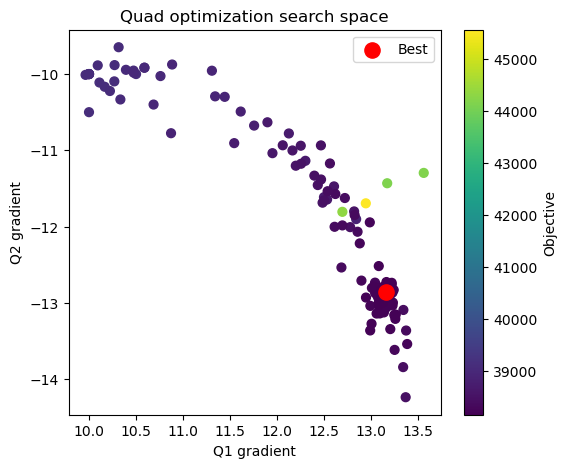

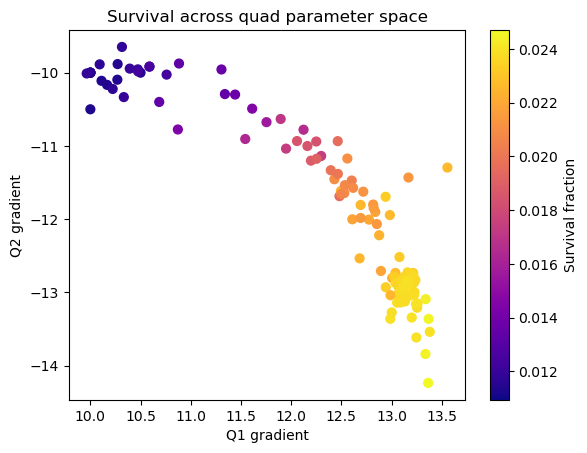

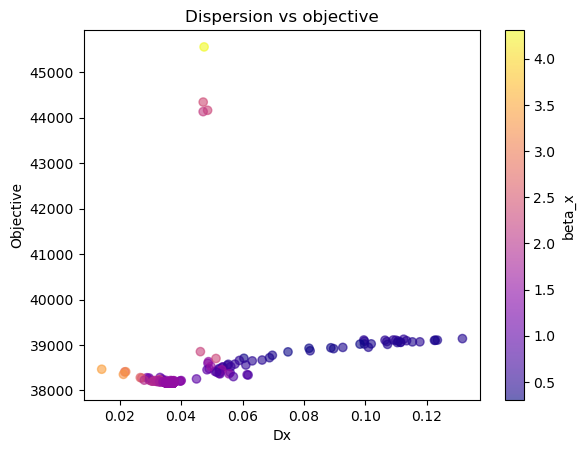

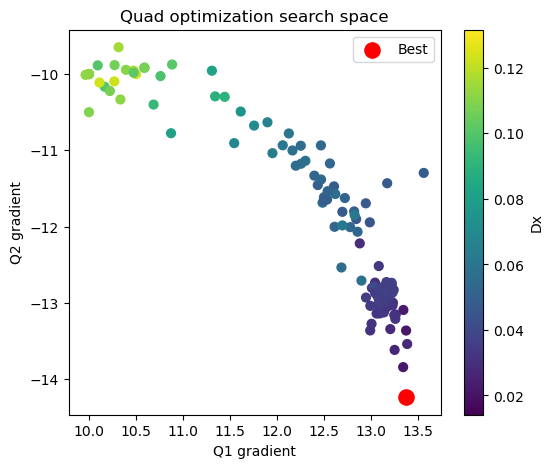

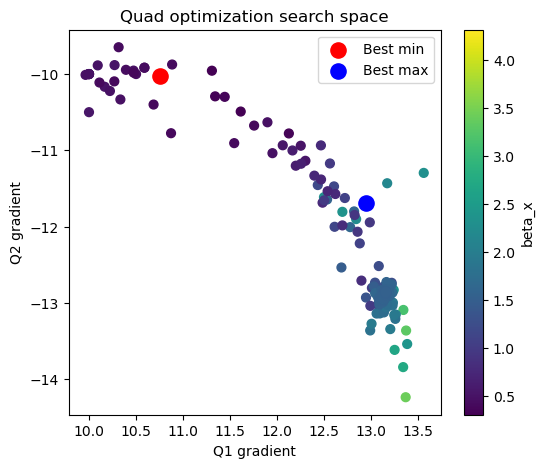

In [71]:
df_hist_beta = pd.DataFrame(history_beta)
plt.figure(figsize=(6,5))

sc = plt.scatter(
    df_hist_beta["Q1_G"],
    df_hist_beta["Q2_G"],
    c=df_hist_beta["objective"].values,
    cmap="viridis",
    s=40
)

best = df_hist_beta.loc[df_hist_beta["objective"].idxmin()]
plt.scatter(
    best["Q1_G"],
    best["Q2_G"],
    color="red",
    s=120,
    label="Best"
)

plt.colorbar(sc, label="Objective")
plt.xlabel("Q1 gradient")
plt.ylabel("Q2 gradient")
plt.title("Quad optimization search space")
plt.legend()
plt.show()

plt.scatter(
    df_hist_beta["Q1_G"],
    df_hist_beta["Q2_G"],
    c=df_hist_beta["survival"],
    cmap="plasma",
    s=40
)
plt.colorbar(label="Survival fraction")
plt.xlabel("Q1 gradient")
plt.ylabel("Q2 gradient")
plt.title("Survival across quad parameter space")
plt.show()
plt.figure()
sc= plt.scatter(df_hist_beta["Dx"], df_hist_beta["objective"], c=df_hist_beta["beta_x"].values, cmap="plasma", alpha=0.6)
plt.colorbar(sc, label="beta_x")
plt.xlabel("Dx")
plt.ylabel("Objective")
plt.title("Dispersion vs objective")
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(
    df_hist_beta["Q1_G"],
    df_hist_beta["Q2_G"],
    c=df_hist_beta["Dx"].values,
    cmap="viridis",
    s=40
)

best = df_hist_beta.loc[df_hist_beta["Dx"].idxmin()]
plt.scatter(
    best["Q1_G"],
    best["Q2_G"],
    color="red",
    s=120,
    label="Best"
)


plt.colorbar(sc, label="Dx")
plt.xlabel("Q1 gradient")
plt.ylabel("Q2 gradient")
plt.title("Quad optimization search space")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(
    df_hist_beta["Q1_G"],
    df_hist_beta["Q2_G"],
    c=df_hist_beta["beta_x"].values,
    cmap="viridis",
    s=40
)

best = df_hist_beta.loc[df_hist_beta["beta_x"].idxmin()]
plt.scatter(
    best["Q1_G"],
    best["Q2_G"],
    color="red",
    s=120,
    label="Best min"
)
best_max = df_hist_beta.loc[df_hist_beta["beta_x"].idxmax()]
plt.scatter(
    best_max["Q1_G"],
    best_max["Q2_G"],
    color="blue",
    s=120,
    label="Best max"
)

plt.colorbar(sc, label="beta_x")
plt.xlabel("Q1 gradient")
plt.ylabel("Q2 gradient")
plt.title("Quad optimization search space")
plt.legend()
plt.show()


In [81]:
if os.path.exists("field_cellB.dat"):
    os.remove("field_cellB.dat")

res_b_beta = minimize(optimize_dipole_safe, x0_dip, args=(df_opt_q_beta, xp[1], yp[1]), method="Nelder-Mead")

print("Optimal dipole parameters:", res_b_beta.x)

iter value

TRYING dipole x = [  1.5 200.  200. ]
Survival: 376/478 → penalty 4.553
OBJECTIVE = 13.026405, Dx=-0.064988, beta_penalty=1064.102413

TRYING dipole x = [  1.575 200.    200.   ]
Survival: 376/478 → penalty 4.553
OBJECTIVE = 13.026405, Dx=-0.064988, beta_penalty=1064.102413

TRYING dipole x = [  1.5 210.  200. ]
Survival: 373/478 → penalty 4.825
OBJECTIVE = 13.009903, Dx=-0.052217, beta_penalty=1146.502249

TRYING dipole x = [  1.5 200.  210. ]
Survival: 373/478 → penalty 4.825
OBJECTIVE = 13.009903, Dx=-0.052217, beta_penalty=1146.502249

TRYING dipole x = [  1.55       206.66666667 206.66666667]
Survival: 372/478 → penalty 4.918
OBJECTIVE = 13.422583, Dx=-0.058432, beta_penalty=1202.581929

TRYING dipole x = [  1.5125     201.66666667 201.66666667]
Survival: 376/478 → penalty 4.553
OBJECTIVE = 13.083158, Dx=-0.065447, beta_penalty=1087.058169

TRYING dipole x = [  1.5 205.  205. ]
Survival: 373/478 → penalty 4.825
OBJECTIVE = 13.009903, Dx=-0.052217, beta_penalty=1146.502

In [82]:
df_opt_b_beta = run_dipole(df_opt_q_beta, B_field=res_b_beta.x[0], B_length=res_b_beta.x[1], Drift2_length=res_b_beta.x[2])
xp_d, yp_d, zp_d = calc_all_params(df_opt_b_beta)
print("FINAL:")
print("Survival:", len(df_opt_b_beta)/len(df_opt_q_beta))
print("Beta:", 0.5*(xp_d[1] + yp_d[1]))
print("Dx:", xp_d[4])

FINAL:
Survival: 0.7803347280334728
Beta: 27.53557071129021
Dx: -0.05210151515543115


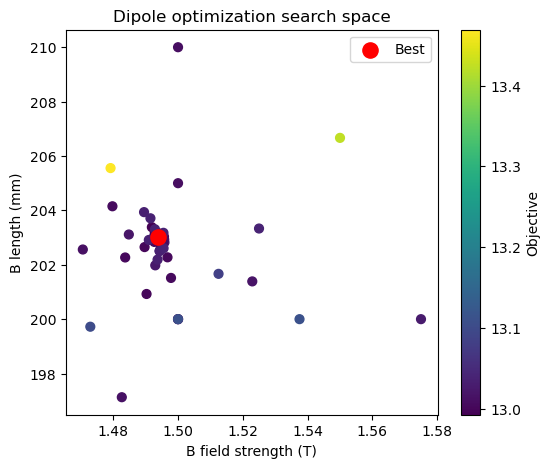

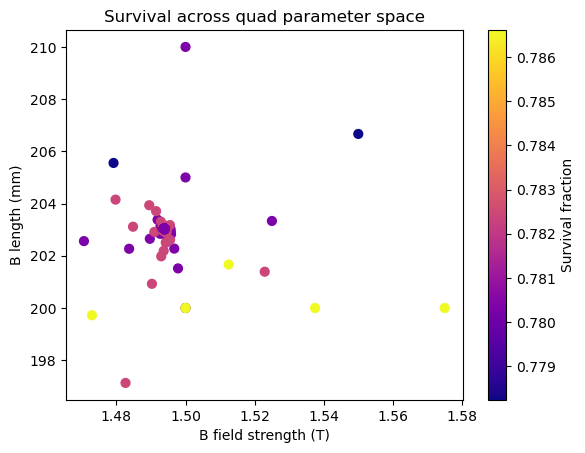

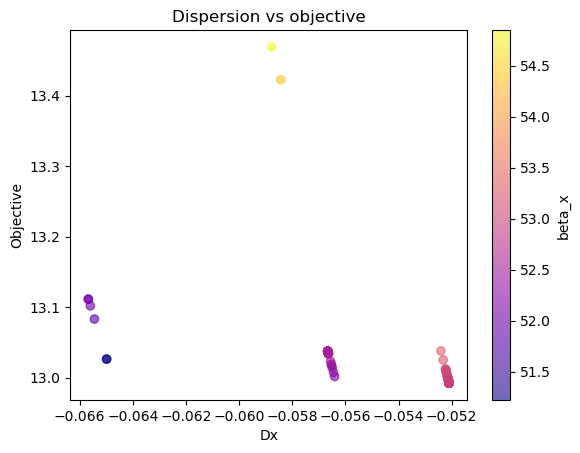

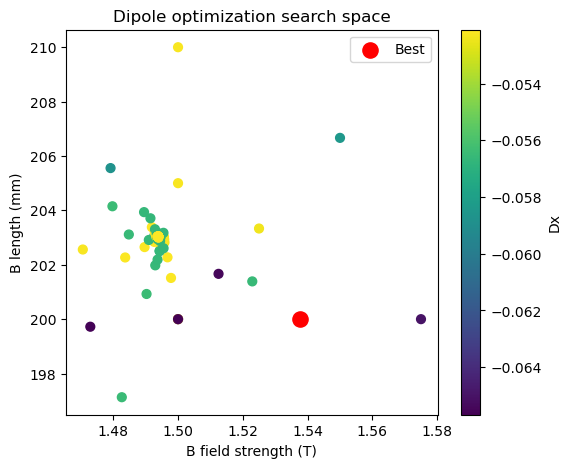

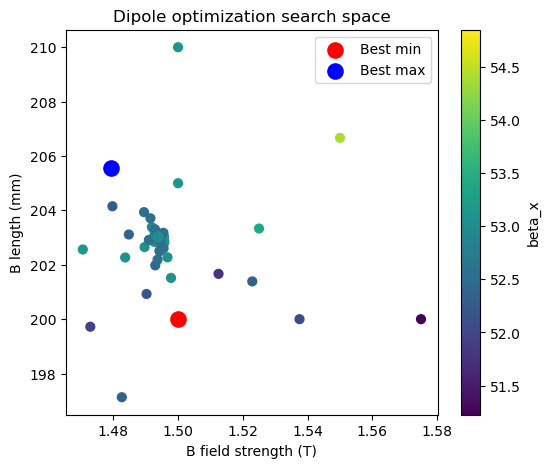

In [85]:
df_hist_b_beta = pd.DataFrame(history_d)
plt.figure(figsize=(6,5))

sc = plt.scatter(
    df_hist_b_beta["B_F"],
    df_hist_b_beta["B_L"],
    c=df_hist_b_beta["objective"].values,
    cmap="viridis",
    s=40
)

best = df_hist_b_beta.loc[df_hist_b_beta["objective"].idxmin()]
plt.scatter(
    best["B_F"],
    best["B_L"],
    color="red",
    s=120,
    label="Best"
)

plt.colorbar(sc, label="Objective")
plt.xlabel("B field strength (T)")
plt.ylabel("B length (mm)")
plt.title("Dipole optimization search space")
plt.legend()
plt.show()

plt.scatter(
    df_hist_b_beta["B_F"],
    df_hist_b_beta["B_L"],
    c=df_hist_b_beta["survival"],
    cmap="plasma",
    s=40
)
plt.colorbar(label="Survival fraction")
plt.xlabel("B field strength (T)")
plt.ylabel("B length (mm)")
plt.title("Survival across quad parameter space")
plt.show()
plt.figure()
sc= plt.scatter(df_hist_b_beta["Dx"], df_hist_b_beta["objective"], c=df_hist_b_beta["beta_x"].values, cmap="plasma", alpha=0.6)
plt.colorbar(sc, label="beta_x")
plt.xlabel("Dx")
plt.ylabel("Objective")
plt.title("Dispersion vs objective")
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(
    df_hist_b_beta["B_F"],
    df_hist_b_beta["B_L"],
    c=df_hist_b_beta["Dx"].values,
    cmap="viridis",
    s=40
)

best = df_hist_b_beta.loc[df_hist_b_beta["Dx"].idxmin()]
plt.scatter(
    best["B_F"],
    best["B_L"],
    color="red",
    s=120,
    label="Best"
)


plt.colorbar(sc, label="Dx")
plt.xlabel("B field strength (T)")
plt.ylabel("B length (mm)")
plt.title("Dipole optimization search space")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(
    df_hist_b_beta["B_F"],
    df_hist_b_beta["B_L"],
    c=df_hist_b_beta["beta_x"].values,
    cmap="viridis",
    s=40
)

best = df_hist_b_beta.loc[df_hist_b_beta["beta_x"].idxmin()]
plt.scatter(
    best["B_F"],
    best["B_L"],
    color="red",
    s=120,
    label="Best min"
)
best_max = df_hist_b_beta.loc[df_hist_b_beta["beta_x"].idxmax()]
plt.scatter(
    best_max["B_F"],
    best_max["B_L"],
    color="blue",
    s=120,
    label="Best max"
)

plt.colorbar(sc, label="beta_x")
plt.xlabel("B field strength (T)")
plt.ylabel("B length (mm)")
plt.title("Dipole optimization search space")
plt.legend()
plt.show()


## Ignore for a bit

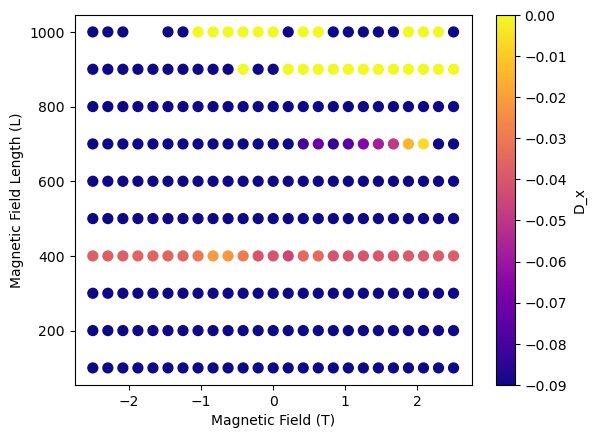

Text(0, 0.5, 'Magnetic Field Length (L)')

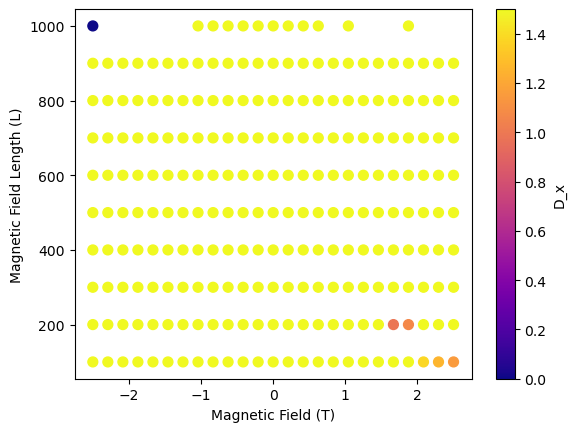

In [63]:
fig, ax = plt.subplots()
sc =ax.scatter(df_scan["B"], df_scan["L"], c=df_scan["Dx"], cmap='plasma', s=50, vmin=-0.09, vmax=0)
fig.colorbar(sc, ax=ax, label='D_x')
ax.set_xlabel("Magnetic Field (T)")
ax.set_ylabel("Magnetic Field Length (L)")
plt.show()
fig, ax = plt.subplots()
sc =ax.scatter(df_scan["B"], df_scan["L"], c=df_scan["beta_x"], cmap='plasma', s=50, vmin=0, vmax=1.5)
fig.colorbar(sc, ax=ax, label='D_x')
ax.set_xlabel("Magnetic Field (T)")
ax.set_ylabel("Magnetic Field Length (L)")

In [31]:
import imageio

# Create folders to save frames
os.makedirs("frames_dx", exist_ok=True)
os.makedirs("frames_betax", exist_ok=True)

# Get all unique DL values
DL_values = sorted(df_scan["DL"].unique())

# --- Dx GIF ---
dx_files = []
for DL0 in DL_values:
    df_DL = df_scan[df_scan["DL"] == DL0]
    pivot_Dx = df_DL.pivot(index="L", columns="B", values="Dx")

    plt.figure()
    plt.imshow(pivot_Dx, aspect="auto", origin="lower")
    plt.colorbar(label="Dx [m]")
    plt.xlabel("B")
    plt.ylabel("L")
    plt.title(f"Dx map at DL={DL0}")
    
    fname = f"frames_dx/Dx_DL{DL0}.png"
    plt.savefig(fname)
    plt.close()
    dx_files.append(fname)

images_dx = [imageio.imread(f) for f in dx_files]
with imageio.get_writer("Dx_maps.gif", mode="I", duration=1.5) as writer:
    for f in dx_files:
        img = imageio.imread(f)
        writer.append_data(img)
print("Dx GIF saved as Dx_maps.gif")

# --- beta_x GIF ---
betax_files = []
for DL0 in DL_values:
    df_DL = df_scan[df_scan["DL"] == DL0]
    pivot_betax = df_DL.pivot(index="L", columns="B", values="beta_x")

    plt.figure()
    plt.imshow(pivot_betax, aspect="auto", origin="lower")
    plt.colorbar(label=r"$\beta_x$ [m]")
    plt.xlabel("B")
    plt.ylabel("L")
    plt.title(f"beta_x map at DL={DL0}")
    
    fname = f"frames_betax/betax_DL{DL0}.png"
    plt.savefig(fname)
    plt.close()
    betax_files.append(fname)

images_betax = [imageio.imread(f) for f in betax_files]
with imageio.get_writer("betax_maps.gif", mode="I", duration=1.5) as writer:
    for f in betax_files:
        img = imageio.imread(f)
        writer.append_data(img)
print("beta_x GIF saved as betax_maps.gif")


Dx GIF saved as Dx_maps.gif
beta_x GIF saved as betax_maps.gif


/tmp/ipykernel_21641/251435781.py:28: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images_dx = [imageio.imread(f) for f in dx_files]
/tmp/ipykernel_21641/251435781.py:31: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(f)
/tmp/ipykernel_21641/251435781.py:53: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images_betax = [imageio.imread(f) for f in betax_files]
/tm

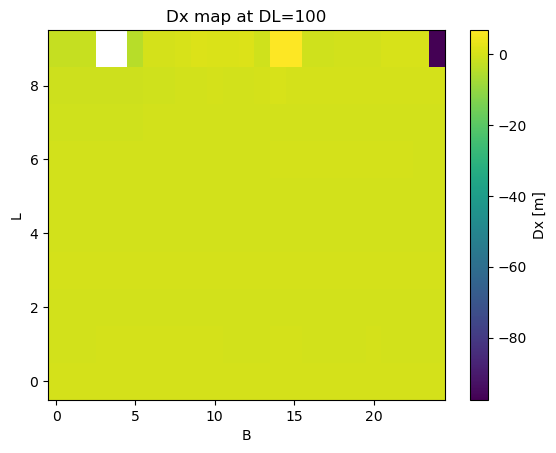

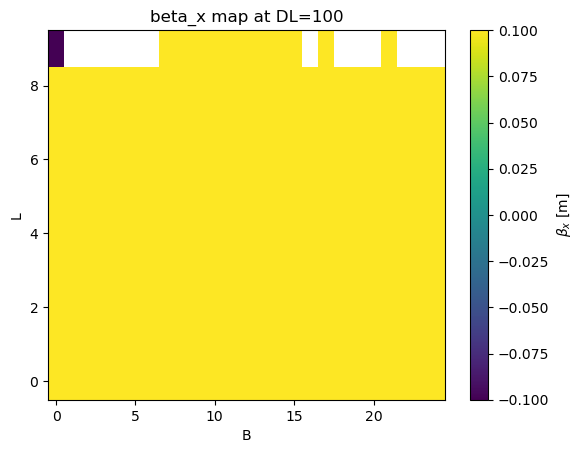

In [32]:
import matplotlib.colors as mcolors
DL0 = 100
df_DL = df_scan[df_scan["DL"] == DL0]
pivot_Dx = (df_DL.pivot(index="L", columns="B", values="Dx"))
# Decide min and max values for the whole dataset
dx_min = df_scan["Dx"].min()
dx_max = df_scan["Dx"].max()

# Define a high-resolution colormap
# For example, 1000 colors → can show differences ~ (dx_max-dx_min)/1000
num_colors = int((dx_max - dx_min)/0.001)  # 0.001 resolution
num_colors = min(num_colors, 10000)  # cap at 10k colors to avoid memory issues

plt.figure()
plt.imshow(
    pivot_Dx,
    aspect="auto",
    origin="lower",
    vmin=dx_min,
    vmax=dx_max
)
"""extent=[
        pivot_Dx.columns.min(),
        pivot_Dx.columns.max(),
        pivot_Dx.index.min(),
        pivot_Dx.index.max()
    ]"""
plt.colorbar(label="Dx [m]")
plt.xlabel("B")
plt.ylabel("L")
plt.title(f"Dx map at DL={DL0}")
plt.show()
# Decide min and max values for the whole dataset
betax_min = df_scan["beta_x"].min()
betax_max = df_scan["beta_x"].max()

pivot_betax = df_DL.pivot(index="L", columns="B", values="beta_x")

plt.figure()
plt.imshow(
    pivot_betax,
    aspect="auto",
    origin="lower",
    vmin=betax_min,
    vmax=betax_max
)
"""extent=[
        pivot_betax.columns.min(),
        pivot_betax.columns.max(),
        pivot_betax.index.min(),
        pivot_betax.index.max()
    ]"""
plt.colorbar(label=r"$\beta_x$ [m]")
plt.xlabel("B")
plt.ylabel("L")
plt.title(f"beta_x map at DL={DL0}")
plt.show()


In [ ]:
df_scan["B"].values

In [ ]:
B00 = -2.5
df_B = df_scan[df_scan["B"] == B00]

# Magnetic Field Strength Somehow Constant?
plt.plot(df_B["L"], df_B["Dx"], color="green")
plt.xlabel("Dipole Length")
plt.ylabel(r"$D_x$")
plt.show()
plt.plot(df_B["L"], df_B["beta_x"], color="orange")
plt.xlabel("Dipole Length")
plt.ylabel(r"$\beta_x$")
plt.show()

In [ ]:
DL0 = 40
df_DL = df_scan[df_scan["DL"] == DL0]

# Magnetic Field Strength Somehow Constant?
plt.plot(df_DL["B"], df_DL["Dx"], color="green")
plt.xlabel("Magnetic Field")
plt.ylabel(r"$D_x$")
plt.show()
plt.plot(df_DL["B"], df_DL["beta_x"], color="orange")
plt.xlabel("Magnetic Field")
plt.ylabel(r"$\beta_x$")
plt.show()


# Dipole Length Matters!
plt.plot(df_DL["L"], df_DL["Dx"], color="green")
plt.xlabel("Dipole Length")
plt.ylabel(r"$D_x$")
closest_idx = np.argmin(np.abs(df_DL["Dx"]))
Dx = df_DL["Dx"].values
L =df_DL["L"].values
B =df_DL["B"].values
closest_b_idx = np.argmin(np.abs(df_DL["beta_x"]))
betax = df_DL["beta_x"].values
plt.title(f"Closest to 0: Dx = {Dx[closest_idx]:.2e} at L = {L[closest_idx]:.6f}")
plt.show()
plt.plot(df_DL["L"], df_DL["beta_x"], color="orange")
plt.xlabel("Dipole Length")
plt.ylabel(r"$\beta_x$")
plt.title(f"Closest to 0: beta_x = {betax[closest_idx]:.2e} at L = {L[closest_idx]:.6f}")
plt.show()

In [158]:
def parse_g4bl_file(filename):
    with open(filename) as f:
        text = f.read()

    pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
    entries = dict(re.findall(pattern, text))

    return {k: float(v) for k, v in entries.items()}

def build_magnet_regions(params):
    magnet_colors = {
        "wedge":  "#FF66CC",
        "Q1":     "#6699FF",
        "Drift1": "#BBBBBB",
        "Q2":     "#3366CC",
        "Drift2": "#999999",
        "B1":     "#FFAA33",
    }

    magnet_order = ["wedge", "Q1", "Drift1", "Q2", "Drift2", "B1"]
    regions = []

    for name in magnet_order:
        z_key = f"{name}_z"
        L_key = f"{name}_length"

        if name == "wedge":
            if "wedge_end" in params:
                z1 = 0.0
                z2 = params["wedge_end"]
                regions.append((z1, z2, magnet_colors[name], name))

        elif z_key in params and L_key in params:
            center = params[z_key]
            length = params[L_key]
            z1 = center - length / 2
            z2 = center + length / 2
            regions.append((z1, z2, magnet_colors[name], name))

    return regions

In [ ]:
def twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y, output_folder="./dispsup_plots"):
    
    # -------------------------------------------------------------------
    # CONVERT TO ARRAYS FOR PLOTTING
    # -------------------------------------------------------------------
    z_positions = np.array(z_positions)
    order = np.argsort(z_positions)

    z_positions = z_positions[order]
    emit_x = np.array(emit_x)[order]
    emit_y = np.array(emit_y)[order]
    beta_x = np.array(beta_x)[order]
    beta_y = np.array(beta_y)[order]
    alpha_x = np.array(alpha_x)[order]
    alpha_y = np.array(alpha_y)[order]
    D_x = np.array(D_x)[order]
    Dp_x = np.array(Dp_x)[order]
    D_y = np.array(D_y)[order]
    Dp_y = np.array(Dp_y)[order]
    emit_z = np.array(emit_z)[order]

    # -------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------
    def make_plot(yvals, ylabel, title, filename, labels=("x", "y")):
        plt.figure(figsize=(7,5))

        # ---- draw magnet shading (already parsed) ----
        for z1, z2, color, label in regions:
            plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)

        # ---- twiss curves ----
        plt.plot(z_positions, yvals[0], 'o-', color="#541352FF", label=f"{labels[0]}-plane")
        plt.plot(z_positions, yvals[1], 's--', color="#3A5E8CFF", label=f"{labels[1]}-plane")

        plt.xlabel("z [mm]")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True)

        # ---- remove duplicate legend entries ----
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.savefig(os.path.join(output_folder, filename))
        plt.close()


    make_plot((emit_x, emit_y), "Emittance [mm·mrad]",
            "Emittance Evolution", "emittance_evolution.png")

    make_plot((beta_x, beta_y), "β-function [m]",
            "Beta Function Evolution", "beta_evolution.png")

    make_plot((alpha_x, alpha_y), "α-function [–]",
            "Alpha Function Evolution", "alpha_evolution.png")

    make_plot((D_x, D_y), "Dispersion D [m]",
            "Dispersion Function", "dispersion_D.png")

    make_plot((Dp_x, Dp_y), "Dispersion Derivative D' [-]",
            "Dispersion Derivative", "dispersion_Dprime.png")

    print(f"All plots saved in '{output_folder}'")


files = ["vd_start_dispsup.txt", "vd_Q1_dispsup.txt", "vd_D1_dispsup.txt", "particles_after_q2uptc.txt", "particles_after_b.txt"]
z_positions = []
emit_x = []
emit_y = []
emit_z = []
beta_x = []
beta_y= []
alpha_x=[]
alpha_y=[]
D_x=[]
Dp_x=[]
D_y=[]
Dp_y=[]

for i in files:
        df1 = read_trackfile(i)
        z_positions.append(np.mean(df1["z"]))
        x_params1, y_params1, z_emit1 = calc_all_params(df1)
        ex, bx, gx, ax, Dx, Dxp = x_params1
        ey, by, gy, ay, Dy, Dyp = y_params1
        emit_x.append(ex)
        emit_y.append(ey)
        beta_x.append(bx)
        beta_y.append(by)
        alpha_x.append(ax)
        alpha_y.append(ay)
        D_x.append(Dx), Dp_x.append(Dxp), D_y.append(Dy), Dp_y.append(Dyp)
        emit_z.append(z_emit1)

g4bl_files = [
    "G4_FinalCooling_dispsup_Q2_run.g4bl",
    "G4_FinalCooling_dispsup_B_run.g4bl",
]

params = {}
for f in g4bl_files:
    params.update(parse_g4bl_file(f))

regions = build_magnet_regions(params)


twissPlot(z_positions, emit_x, emit_y, emit_z, beta_x, beta_y, alpha_x, alpha_y, D_x, Dp_x, D_y, Dp_y)

In [276]:
def B_from_theta(theta, L_mm, p_GeV=0.879):
    L_m = L_mm * 1e-3
    return theta * p_GeV / (0.3 * L_m)

In [ ]:
def optimize_dipole_aa(x, df_in, beta_x_ref, beta_y_ref,
                    w_disp=10.0, w_beta=100.0, w_len=5.0,
                    survival_threshold=0.95):

    theta, L_mm, Drift2_length = x

    # compute B from theta
    B_field = B_from_theta(theta, L_mm)

    # hard physical bounds
    if B_field < 0.1 or B_field > 3.0:
        return 1e6 + abs(B_field)

    result = run_dipole(df_in, B_field, L_mm, Drift2_length)
    if result is None or len(result) < 100:
        return 1e6

    mask, *_ = check_dipole_clearance(df_in, B_field, L_mm, 50)
    survival_frac = np.mean(mask)

    if survival_frac < survival_threshold:
        return 1e6 + 1e4*(survival_threshold - survival_frac)

    df_survived = result[mask]
    x_params_d, y_params_d, _ = calc_all_params(df_survived)

    Dx = x_params_d[4]
    beta_x = x_params_d[1]
    beta_y = y_params_d[1]

    # dispersion target
    disp_target = abs(theta * L_mm / 2)
    disp_penalty = ((Dx - disp_target) / disp_target)**2

    # beta mismatch
    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 \
                 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    # discourage tiny magnets
    length_penalty = (50.0 / L_mm)**2

    if disp_penalty > 5.0:
        return w_disp * disp_penalty

    val = (
        w_disp * disp_penalty +
        w_beta * beta_penalty +
        w_len  * length_penalty
    )

    print(f"θ={theta:.3f}, L={L_mm:.1f}, B={B_field:.2f}, Obj={val:.3e}")
    return val
x0_dip = [0.15, 200.0, 100.0]  # theta [rad], L [mm], drift [mm]

bounds_dip = [
    (0.05, 0.30),   # bend angle
    (80, 400),      # dipole length
    (20, 1000)      # drift
]

res_dip = minimize(
    optimize_dipole_aa,
    x0_dip,
    args=(df_opt, b_dict['Beta_x'], b_dict['Beta_y']),
    method="Nelder-Mead", bounds=bounds_dip
)

In [ ]:
def beam_size(beta, eps, n_sigma=1):
    """
    Compute full beam width/height in mm for given beta (m) and emittance (mm·mrad)
    """
    sigma = np.sqrt(beta * eps * 1e3)  # convert sigma (mm) = sqrt(m * 1e3 * mm)
    return 2 * n_sigma * sigma
B_width = beam_size(x_params[1], x_params[0])
B_height = beam_size(y_params[1], y_params[0])
print(B_height, B_width)

In [ ]:
def optimize_dipole(x, df_in, beta_x_ref, beta_y_ref, w_disp=10.0, w_beta=1000.0, w_clear=100.0, D_tol=1e-3, survival_threshold=0.95):
    """
    Optimize dipole parameters but only for distributions that survive >= survival_threshold.
    x = [B_field, B_length, Drift2_length]
    """
    B_field, B_length, Drift2_length = x
    total_cost = 0
    # Run G4BL with these parameters
    result = run_dipole(df_in, B_field, B_length, Drift2_length)
    if result is None or len(result) < 100:
        return 1e6 + 10*(
            abs(B_field) + B_length + Drift2_length)

    # Check which particles survive
    mask, r_L_mm, delta_r_mm = check_dipole_clearance(df_in, B_field, B_length, 100/2)
    
    survival_frac = np.mean(mask)
    if survival_frac < survival_threshold:
        # Penalize strongly: configuration not feasible
        return 1e6 + 1e3*(survival_threshold - survival_frac)

    # Compute dispersion & beta from survived particles
    df_survived = result[mask] if isinstance(result, np.ndarray) else result[mask.values]
    x_params_d, y_params_d, _ = calc_all_params(df_survived)
    Dx, beta_x = x_params_d[4], x_params_d[1]
    Dy, beta_y = y_params_d[4], y_params_d[1]

    disp_penalty = Dx**2
    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    val = w_disp*disp_penalty + w_beta * beta_penalty
    print("OBJECTIVE =", val)
    return val


# initial guess: B_field (T), B_length (mm), Drift2_length (mm)
x0_dip = [1.5, 200.0, 100.0]

# bounds
bounds_dip = [(0.1, 3.0),  # B_field
              (50, 400),   # B_length
              (20, 1000)]  # Drift2_length

res_dip = minimize(optimize_dipole, x0_dip, args=(df_opt, b_dict['Beta_x'], b_dict['Beta_y']),
                method="Nelder-Mead", bounds=bounds_dip)

print("Optimal dipole parameters:", res_dip.x)


In [ ]:
# Run a single case of optimal values
opt_params = {
    "Drift2_length": res_dip.x[2], 
    "Drift2_width": 100,
    "Drift2_height": 100,
    "Drift2_z": (L_centerline + res.x[0] + res.x[5] + res.x[2]) + res_dip.x[2]/2,
    "B1_field": res_dip.x[0],
    "B1_z": (L_centerline + res.x[0] + res.x[5] + res.x[2]) + res_dip.x[2] + res_dip.x[1]/2,
    "B1_end": (L_centerline + res.x[0] + res.x[5] + res.x[2]) + res_dip.x[2] + res_dip.x[1],
    "B1_length": res_dip.x[1],
    "B1_width": 100,
    "B1_height": 100
    }
print(opt_params)
write_input_from_template("G4_FinalCooling_dispsup_B.g4bl", opt_params, "G4_FinalCooling_dispsup_B_opt.g4bl")
if os.path.exists("field_cellB.dat"):
    os.remove("field_cellB.dat")
result = subprocess.run(["g4bl", "G4_FinalCooling_dispsup_B_opt.g4bl"], capture_output=True, text=True, check=True)
df_dip = read_trackfile("particles_after_b.txt")
x_params_dip, y_params_dip, z_emit_dip = calc_all_params(df_dip)
D_dict_dip = {"D_x": x_params_dip[4], "D'_x": x_params_dip[5], "D_y": y_params_dip[4], "D'_y": y_params_dip[5]}
b_dict_dip = {"Beta_x": x_params_dip[1], "Beta_y": y_params_dip[1]}
print(D_dict_dip, r"Epsilon_z: "+str(z_emit_dip), b_dict_dip)

## Scrap

In [ ]:
def run_dipole_quad(df, Q1_length, Q1_gradient, B_field, B_length, Drift2_length, Drift3_length, Drift2_z=0, Q_radius=res.x[4], thickness=5):
    """Run dipole simulation with given parameters."""
    params = {
        "Q1_length": Q1_length,
        "Q1_gradient": Q1_gradient,
        "Q1_z": Drift2_z + Drift2_length + B_length + Drift3_length + Q1_length/2,
        "Q1_end": Drift2_z + Drift2_length + B_length + Drift3_length + Q1_length,
        "radius_q": Q_radius,
        "thickness": thickness,
        "Drift2_length": Drift2_length, 
        "Drift2_width": B_width,
        "Drift2_height": B_height,
        "Drift2_z": Drift2_z + Drift2_length/2,
        "B1_field": B_field,
        "B1_z": Drift2_z + Drift2_length + B_length/2,
        "B1_end": Drift2_z + Drift2_length + B_length,
        "B1_length": B_length,
        "B1_width": B_width,
        "B1_height": B_height,
        "Drift3_length": Drift2_length, 
        "Drift3_width": B_width,
        "Drift3_height": B_height,
        "Drift3_z": Drift2_z + Drift2_length + B_length + Drift3_length/2,
    }
    write_input_from_template("G4_FinalCooling_dispsup_BQ.g4bl", params, "G4_FinalCooling_dispsup_BQ_run.g4bl")
    outfile = "G4_FinalCooling_dispsup_BQ_run.g4bl"
    print("=== DEBUG FILE CHECK ===")
    print("Absolute path:", os.path.abspath(outfile))
    print("Last modified:", time.ctime(os.path.getmtime(outfile)))
    print("========================")

    # Print Q1 block robustly (NOT by line number)
    print("---- B BLOCK ----")
    with open(outfile, "r") as f:
        printing = False
        for line in f:
            if line.startswith("genericbend B"):
                printing = True
            if printing:
                print(line.rstrip())
            if printing and line.strip() == "":
                break
    print("-------------------")
    return run_g4beam(df, "G4_FinalCooling_dispsup_BQ_run.g4bl")

In [ ]:
def optimize_dipole_quad(x, df_in, beta_x_ref, beta_y_ref, w_disp=10.0, w_beta=1000.0, w_clear=100.0, D_tol=1e-3, survival_threshold=0.95):
    """
    Optimize dipole parameters but only for distributions that survive >= survival_threshold.
    x = [B_field, B_length, Drift2_length]
    """
    Q_length, Q_gradient, B_field, B_length, Drift2_length, Drift3_length = x
    total_cost = 0
    # Run G4BL with these parameters
    result = run_dipole_quad(df_in, Q_length, Q_gradient, B_field, B_length, Drift2_length, Drift3_length)
    if result is None or len(result) < 100:
        return 1e6

    # Check which particles survive
    mask, r_L_mm, delta_r_mm = check_dipole_clearance(df_in, B_field, B_length, 100/2)
    
    survival_frac = np.mean(mask)
    if survival_frac < survival_threshold:
        # Penalize strongly: configuration not feasible
        return 1e6 + 1e3*(survival_threshold - survival_frac)

    # Compute dispersion & beta from survived particles
    df_survived = result[mask] if isinstance(result, np.ndarray) else result[mask.values]
    x_params_d, y_params_d, _ = calc_all_params(df_survived)
    Dx, beta_x = x_params_d[4], x_params_d[1]
    Dy, beta_y = y_params_d[4], y_params_d[1]

    disp_penalty = Dx**2
    beta_penalty = ((beta_x - beta_x_ref)/beta_x_ref)**2 + ((beta_y - beta_y_ref)/beta_y_ref)**2

    val = w_disp*disp_penalty + w_beta * beta_penalty
    print("OBJECTIVE =", val)
    return val


# initial guess: Q_length (mm), Q_gradient (T/m), B_field (T), B_length (mm), Drift2_length (mm), Drift3_length (mm)
x0_dipq = [200.0, 10, 1.5, 200.0, 100.0, 100.0]

# bounds
bounds_dipq = [(20, 1000),(1, 30), (0.1, 3.0),
            (50, 400),(20, 1000),(20, 1000)]

res_dipq = minimize(optimize_dipole_quad, x0_dipq, args=(df_opt, b_dict['Beta_x'], b_dict['Beta_y']),
                method="Nelder-Mead", bounds=bounds_dipq)

print("Optimal dipole parameters:", res_dipq.x)


# Phase rotation

The following are taken as constants, as they are primarily constrained by technical limitations. The optimal RF gradient is heavily dependent on both of these.
- **Drift length**: Longer drift length will give better results
- **RF frequency**: Lower frequency will usually give better results. There's an optimal point, but I believe it's lower than practical

We then optimize the RF phase, cavity length, and gradient

In [ ]:
drift_length = 16000
rf_freq = 0.025

# Function to optimize
def func(x):
    rf_phase, rf_length, rf_grad = x
    drift_to_start = drift_length-rf_length/2
    post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
    post_cavity = run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))
    pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
    return np.std(p_total(cut_pz(pre_w2)))

# Run optimization
optim_result = minimize(func, [0, 4700, 7], method="Nelder-Mead", bounds=((-90, 90), (2000, 6000), (1, 10)), options=dict(fatol=1e-6))

# Get results
rf_phase, rf_length, rf_grad = optim_result.x
print(f"Phase = {rf_phase:.2f} deg\nLength = {rf_length:.0f} mm\nGradient = {rf_grad:.2f} MV/m\nFrequency = {rf_freq*1000:.1f} MHz")

# Runs a single case with the optimal parameters and add the transverse back in
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(no_transverse, drift_to_start))
post_cavity = cut_pz(recenter_t(run_g4beam(post_drift, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad)))
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print_all_params(pre_w2)

# Second wedge

Optimize the second wedge in the same way as the first

In [ ]:
# Function to optimize
def func(x):
    length, angle = x
    return emittances(cut_outliers(run_distribution(pre_w2, length, angle, vd_dist, axis=1)))[1]

# Run optimization
optim_result = minimize(func, [5.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=1e-6))

# Get results
w2_length, w2_angle = optim_result.x
print(f"Length = {w2_length:.2f} mm\nAngle = {w2_angle:.1f} deg")

# Runs a single case with the optimal parameters
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
print_all_params(post_w2)

# Do cuts at this point
post_w2_cut = cut_outliers(post_w2)
print_all_params(post_w2_cut)

# Save/load result

In [33]:
# Parameter list
PARAMS = [
    "t_emit",
    "momentum",
    "beta",
    "alpha",
    "l_emit",
    "pz_std",
    "vd_dist",
    "w1_length",
    "w1_angle",
    "w2_length",
    "w2_angle",
    "drift_length",
    "rf_freq",
    "rf_phase",
    "rf_length",
    "rf_grad"
]

In [ ]:
# Show parameters
{k:globals()[k] for k in PARAMS}

In [8]:
# Input parameters
parameters = {'t_emit': 0.145,
 'momentum': 100,
 'beta': 0.03,
 'alpha': 1,
 'l_emit': 1,
 'pz_std': 1,
 'vd_dist': 24,
 'w1_length': 9.20751061747799,
 'w1_angle': 49.78231333988419,
 'w2_length': 6.724887901827298,
 'w2_angle': 42.245718529695516,
 'drift_length': 16000,
 'rf_freq': 0.025,
 'rf_phase': 0.001987066319906211,
 'rf_length': 5153.756925848655,
 'rf_grad': 4.046563465382562}
globals().update(parameters)

In [ ]:
# Save parameter set
parameters = {k:globals()[k] for k in PARAMS}
filename = "results/parameters/"+input("Enter run name to save: ")+".pkl"
with open(filename, "wb+") as file:
    pickle.dump(parameters, file)
    print("Saved to", filename)

In [ ]:
# Load parameter set
filename = "results/parameters/"+input("Enter run name to load: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    globals().update(parameters)
    print("Loaded from", filename)

In [ ]:
# View parameter set
filename = "results/parameters/"+input("Enter run name to view: ")+".pkl"
with open(filename, "rb+") as file:
    parameters = pickle.load(file)
    print("Viewing", filename)
    print(parameters)

In [255]:
vd_dist=36

# Analyze single case

In [ ]:
# Tweak parameters
rf_phase += 180
rf_phase

In [ ]:
# Run best case
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)
pre_w1["PDGid"] = -13
print("Running first wedge")
post_w1 = run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0)
post_correct = remove_dispersion(post_w1)
reverse_transverse = post_correct.copy(deep=True)
reverse_transverse["Px"] *= -1
reverse_transverse["Py"] *= -1
drift_to_start = drift_length-rf_length/2
post_drift = recenter_t(z_prop(post_correct, drift_to_start))
no_transverse = remove_transverse(post_drift)
print("Running RF cavity")
post_cavity = cut_pz(recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad, nparticles=len(no_transverse))), tails=0.15)
pre_w2 = recombine_transverse(post_cavity, reverse_transverse)
print("Running second wedge")
post_w2 = run_distribution(pre_w2, w2_length, w2_angle, vd_dist, axis=1)
post_w2_cut = recenter_t(cut_outliers(post_w2))
print_all_params(post_w2_cut)
beep()

In [ ]:
# Make some phase space plots
PLOT_TARGETS = [pre_w1, post_correct, post_drift, pre_w2, remove_dispersion(post_w2_cut)]
PLOT_TITLES = ["Initial distribution", "After first wedge", "After drift", "After RF cavity and refocusing", "After second wedge"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(16, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
SAMPLE_DISTS = [pre_w1, post_correct, pre_w2, remove_dispersion(post_w2_cut)]
SAMPLE_TITLES = ["Initial distribution", "After first wedge", "After RF cavity + 10% cut", "After second wedge + 4 sigma cut"]
VARIABLE_NAMES = ["x emit (μm)", "y emit (μm)", "z-emit (mm)", "sigma-p (MeV/c)", "sigma-t (ns)", "Beam remaining"]
VARIABLE_FUNCS = [
    lambda df: emittances(df)[0]*1000,
    lambda df: emittances(df)[1]*1000,
    lambda df: emittances(df)[2],
    lambda df: np.std(p_total(df)),
    lambda df: np.std(df["t"]),
    lambda df: len(df) / len(pre_w1)
]
table = [[n] + [y(x) for y in VARIABLE_FUNCS] for n, x in zip(SAMPLE_TITLES, SAMPLE_DISTS)]
print(tabulate(
    table,
    headers=["Stage"] + VARIABLE_NAMES,
    # tablefmt="latex_raw",
    floatfmt=(None, ".1f", ".1f", ".3f", ".3f", ".3f", ".1%")
))

## Anomaly investigation

This is going insane

In [ ]:
momentum = 100
pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
pre_w1["PDGid"] = -13
run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0, debug=True)

In [ ]:
momentums = list(range(50, 101, 10))
results = list() #  Yeah we're back to the old days now
for momentum in tqdm(momentums):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    pre_w1["PDGid"] = -13
    results.append(run_distribution(pre_w1, w1_length, w1_angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 12)
for momentum, x, ax in zip(momentums, results, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
pass

In [ ]:
results[0]["PDGid"]

In [ ]:
angles = [30, 40, 50, 60]
momentum = 70
results1 = list() #  Yeah we're back to the old days now
for angle in tqdm(angles):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results1.append(run_distribution(pre_w1, w1_length, angle, vd_dist, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for angle, x, ax in zip(angles, results1, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{angle} deg")
pass

In [ ]:
lengths = [3, 6, 9, 12]
momentum = 70
results2 = list() #  Yeah we're back to the old days now
for length in tqdm(lengths):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
    results2.append(run_distribution(pre_w1, length, w1_angle, 40, axis=0))
beep()

In [ ]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
axs = axs.flatten()
fig.set_size_inches(10, 8)
for length, x, ax in zip(lengths, results2, axs):
    ax.hist(p_total(x), bins=200, range=(40, 110))
    ax.axvline(momentum, color="red", linestyle="--")
    ax.set_title(f"{length} mm")
pass

In [ ]:
fig, ax = plt.subplots()
ax.hist(p_total(post_w2_cut), bins=200)
select_bottom, select_top = 60.5, 62.5
ax.axvline(select_bottom, color="r", linestyle="--")
ax.axvline(select_top, color="r", linestyle="--")
anomaly = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
pre_anomaly = pre_w2.loc[anomaly["EventID"]]
post_anomaly = run_distribution(pre_anomaly, w2_length, w2_angle, vd_dist, axis=1)

In [ ]:
# Show the anomaly
PLOT_TARGETS = [pre_w2, pre_anomaly, post_w2_cut, post_anomaly]
PLOT_TITLES = ["Before (full)", "Before (anomalous)", "After (full)", "After (anomalous)"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-7.5, 7.5], [-30, 30]]
L_RANGES = [[-10, 10], [40, 110]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(10, 8)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
# fig.suptitle(f"temit={t_emit*1000:.0f} μm, σP={pz_std:.2f} MeV/c")

In [ ]:
run_distribution(pre_w1, w2_length, w2_angle, vd_dist, axis=1, debug=True)

In [ ]:
fig, ax = plt.subplots()
ax.hist(post_w2_cut["y"], bins=200)
pass

In [ ]:
p_ranges = [(58.5+2*i, 60.5+2*i) for i in range(7)]

fig, axes = plt.subplots(ncols = 2, nrows = len(p_ranges), layout="constrained")
fig.set_size_inches(6, 3*len(p_ranges))
for i, r in enumerate(p_ranges):
    ax = axes[i][0]
    ax.hist(p_total(post_w2_cut), bins=200, range=(55, 90))
    select_bottom, select_top = r
    ax.axvline(select_bottom, color="r", linestyle="--")
    ax.axvline(select_top, color="r", linestyle="--")

    selected = post_w2_cut[(p_total(post_w2_cut) < select_top) & (p_total(post_w2_cut) > select_bottom)]
    pre_selected = pre_w2.loc[selected["EventID"]]

    ax = axes[i][1]
    ax.hist2d(pre_selected["y"], pre_selected["Py"], bins=50, range=T_RANGES)
    ax.set_xlabel("y")
    ax.set_ylabel("Py")

## Two optimal wedges (regenerated)

In [35]:
# Range to scan
angles = np.linspace(30, 60, 20)
lengths = np.linspace(5, 11, 20)

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w2, length, angle, 24, axis=1)

results = run_scan(fun, (lengths, angles), filename="results/second_wedge_length_angle.pkl")
beep()

In [ ]:
def fun(length, angle):
    return run_distribution(pre_w1, length, angle, 24, axis=0)

results = run_scan(fun, (lengths, angles), filename="results/first_wedge_length_angle.pkl")
beep()

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")
fig.set_size_inches(10, 4)

# First wedge

with open("results/first_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[0], results))
meshx, meshy = mesh

cax = ax1.contourf(meshx, meshy, meshz, levels=50)
ax1.set_xlabel("First wedge length (mm)")
ax1.set_ylabel("First wedge half-angle (deg)")
ax1.set_title("First wedge")
plt.colorbar(cax, ax=ax1).set_label("x-emittance (mm)")

ax1.plot(w1_length, w1_angle, 'rx')
ax1.annotate(f"{w1_length:.2f} mm, {w1_angle:.2f} deg", (w1_length, w1_angle), c="red", xytext = (-30, 10), textcoords="offset points")

# Second wedge

with open("results/second_wedge_length_angle.pkl", "rb") as file:
    results = pickle.load(file)

mesh = np.meshgrid(lengths, angles)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: emittances(cut_outliers(df))[1], results))
meshx, meshy = mesh

cax = ax2.contourf(meshx, meshy, meshz, levels=50)
ax2.set_xlabel("Second wedge length (mm)")
ax2.set_ylabel("Second wedge half-angle (deg)")
ax2.set_title("Second wedge")
plt.colorbar(cax, ax=ax2).set_label("y-emittance (mm)")

ax2.plot(w2_length, w2_angle, 'rx')
ax2.annotate(f"{w2_length:.2f} mm, {w2_angle:.2f} deg", (w2_length, w2_angle), c="red", xytext = (-30, 10), textcoords="offset points")

## Frequency and gradient (regenerated)

In [90]:
rf_freqs = np.linspace(0.01, 0.06, 20)
rf_grads = np.linspace(1,10,20)

In [ ]:
# get no_transverse from above

def fun(rf_grad, rf_freq):
    return recenter_t(run_g4beam(no_transverse, "G4_RFCavity.g4bl", RF_length=rf_length, frfcool=rf_freq, ficool=rf_phase, Vrfcool=rf_grad))

results = run_scan(fun, (rf_grads, rf_freqs), "results/rf_grad_freq_16m.pkl")

In [ ]:
with open("results/rf_grad_freq_16m.pkl", "rb") as file:
    results = pickle.load(file)
mesh = np.meshgrid(rf_grads, rf_freqs)
meshz = qmap_to_meshgrid(mesh, calc_quantity(lambda df: np.std(cut_pz(df)["Pz"]), results))
meshx, meshy = mesh

meshy = 1000 * meshy # Scale to MHz

fig, ax = plt.subplots()
cax = ax.contourf(meshx, meshy, meshz, levels=50)
ax.set_xlabel("RF gradient (MV/m)")
ax.set_ylabel("RF frequency (MHz)")
plt.colorbar(cax).set_label("sigma-Pz (MeV/c)")

minpoint = np.unravel_index(np.argmin(meshz), meshz.shape)
ax.plot(rf_grad, rf_freq*1000, 'rx')
ax.annotate(f"{rf_grad:.2f} MV/m, {rf_freq*1000:.1f} MHz", (rf_grad, rf_freq*1000), c="red", xytext = (-30, 10), textcoords="offset points")

# Scan of optimal over pz_std

In [18]:
t_emit = 0.110  # mm
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_stds = np.linspace(0.8, 1.1, 6)
vd_dist = 24    # mm

In [ ]:
# Meta-function (containing optimization)
def metafun(pz_std):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7.5, 45], method="Nelder-Mead", bounds=((1, 10), (30, 70)), options=dict(fatol=2e-4))

run_scan(metafun, (pz_stds,), filename="results/optimal_scan.pkl", trials=5)

In [ ]:
with open("results/optimal_scan.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"$\sigma p$ (MeV/c)")
ax1.set_ylabel("minimum x emit (mm)")

ax2.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"$\sigma p$ (MeV/c)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(pz_stds, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"$\sigma p$ (MeV/c)")
ax3.set_ylabel("optimal half-angle (deg)")

In [ ]:
calc_quantity(optim_fun, results)

In [ ]:
1e-5

In [ ]:
calc_quantity(optim_fun, results)[(0.8,)][1] / 1e-4